<a href="https://colab.research.google.com/github/jovanailin/PRMLprojekat/blob/main/Diamonds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Test - update notebook - Jovana

Test - update notebook - Sonja

# PRML - Course Project
## Comparative Study of Classical Methods on the Diamonds Dataset

In this project we perform two supervised-learning tasks on the same dataset:

1. **Classification** - predict whether a diamond has a premium cut
   (`Premium` = {Premium, Ideal}) or not (`Non-Premium` = {Fair, Good, Very Good}).
2. **Regression** - predict a diamond's price.

Baseline methods:
* Classification: Gaussian Naive Bayes and k-NN classification.
* Regression: Linear Regressionand k-NN regression.

Extension: Random Forest for both tasks.

All the models are implemented from scratch, and the external libraries (`scikit-learn`) are used only for validation/comparison.

### Dataset

The **Diamonds** dataset contains 53,940 round-cut diamonds with 10 attributes:

- `carat` (weight)
- `cut` (quality, 5 grades),
- `color` (D best, J worst),
- `clarity` (IF best, I1 worst)
- `depth` (total depth percentage)
- `table` (table width percentage)
- physical dimensions `x, y, z` (mm)
- `price` (USD)

# Data loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

In [ ]:
df = pd.read_csv('/content/diamonds.csv')

print('dataset shape:', df.shape)
print(df.head())
print("\n")
print(df.info())

dataset shape: (53940, 11)
   Unnamed: 0  carat      cut color clarity  depth  table  price     x     y  \
0           1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98   
1           2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84   
2           3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07   
3           4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23   
4           5   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35   

      z  
0  2.43  
1  2.31  
2  2.31  
3  2.63  
4  2.75  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  f

In [ ]:
df = df.drop(columns=['Unnamed: 0'])
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Data cleaning

In [ ]:
# Check if any numerical column has 0 values
numeric_cols = ['carat','depth','table','price','x','y','z']
zeros = (df[numeric_cols] == 0).sum()
print("Zero counts per numerical column:")
print(zeros[zeros > 0])

Zero counts per numerical column:
x     8
y     7
z    20
dtype: int64


In [ ]:
# It is impossible for a diamond do have 0 for a physical dimension, so we remove those rows from the dataset
bad = (df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)
df = df[~bad].reset_index(drop=True)
print(bad.sum(), 'dropped')

20 dropped


## EDA


Numerical summary:


,carat,depth,table,price,x,y,z
count,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000
mean,0.797698,61.749514,57.456834,3930.993231,5.731627,5.734887,3.540046
std,0.473795,1.432331,2.234064,3987.280446,1.119423,1.140126,0.702530
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5323.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


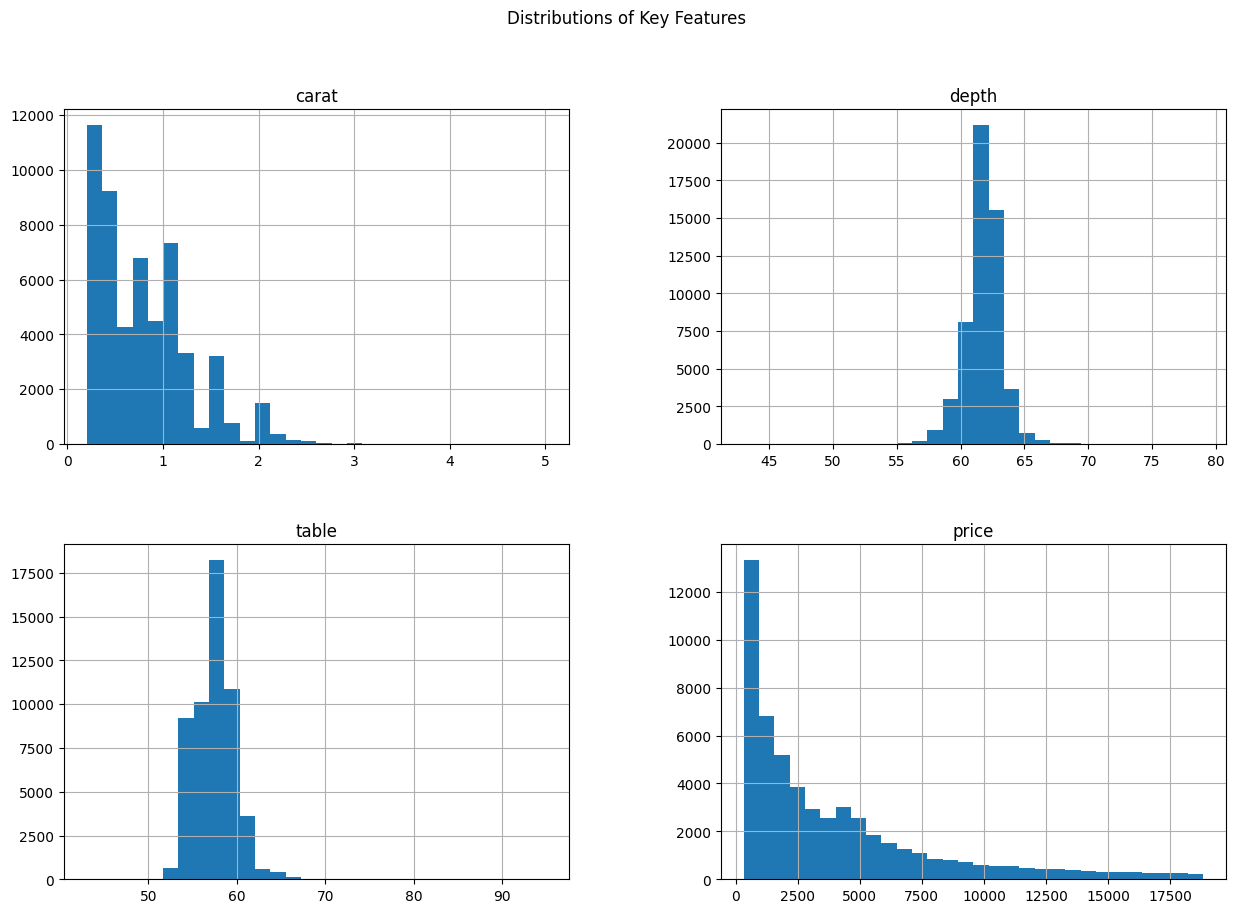

In [ ]:
# Summary statistics
print("\nNumerical summary:")
display(df.describe())

print("\n")

# Visualize distributions of main numerical features
df[['carat', 'depth', 'table', 'price']].hist(bins=30, figsize=(15, 10))
plt.suptitle("Distributions of Key Features")
plt.show()

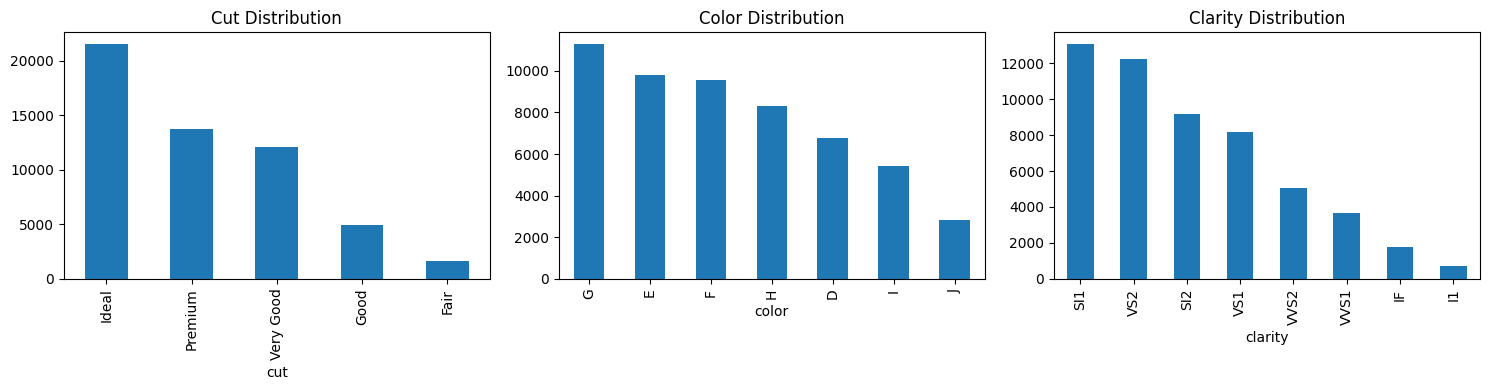

In [ ]:
# Categorical distributions
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

df['cut'].value_counts().plot(kind='bar', ax=ax[0], title='Cut Distribution')
df['color'].value_counts().plot(kind='bar', ax=ax[1], title='Color Distribution')
df['clarity'].value_counts().plot(kind='bar', ax=ax[2], title='Clarity Distribution')

plt.tight_layout()
plt.show()

## Data preparation

### Feature engineering

New features:

- `color_ord`, `clarity_ord`, `cut_ord` - from categorical to ordinal. `cut_ord` is used only in regression (cut builds the premium target).
- `volume` - x*y*z, size.
- `log_carat`
- `log_price`
- `price_per_carat` - price/carat

In [ ]:
COLOR_ORD   = {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7}
# J = worst, D = best (GIA scale, not alphabetical order)
CLARITY_ORD = {'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4, 'VS1': 5, 'VVS2': 6, 'VVS1': 7, 'IF': 8}
# I1 = worst, IF = best
CUT_ORD     = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}

def add_features(d):
    d = d.copy()
    d['color_ord']   = d['color'].map(COLOR_ORD)
    d['clarity_ord'] = d['clarity'].map(CLARITY_ORD)
    d['cut_ord']     = d['cut'].map(CUT_ORD)
    d['volume']      = d['x'] * d['y'] * d['z']
    d['log_carat']   = np.log(d['carat'])
    d['log_price']   = np.log(d['price'])
    d['price_per_carat'] = d['price'] / d['carat']
    return d

data = add_features(df)
print('features added:', [c for c in data.columns if c not in df.columns])

features added: ['color_ord', 'clarity_ord', 'cut_ord', 'volume', 'log_carat', 'log_price', 'price_per_carat']


In [ ]:
# Stratified 6,000-row subsample (stratified on target to preserve class proportions)
def stratified_sample(d, col, n, seed=0):
    frac = n / len(d)
    parts = [g.sample(frac=frac, random_state=seed) for _, g in d.groupby(col)]
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

sample = stratified_sample(data, 'cut', 6000, seed=0)
print('subsample shape:', sample.shape)

subsample shape: (6000, 17)



# Part A - Classification (premium vs non-premium cut)

### Research questions:
**RQ1** - Can the premium/non-premium cut be recovered from a diamond's attributes?

**RQ2** - What are the strongest discriminators?

**RQ3** - Which model separates the classes
best, and how do their hyperparameters matter?

Original cut distribution:
cut
Ideal        2398
Premium      1533
Very Good    1344
Good          545
Fair          179
Name: count, dtype: int64

Binary target (premium):
premium
Non-Premium    2068
Premium        3931
Name: count, dtype: int64
proportions: {0: 0.345, 1: 0.655}


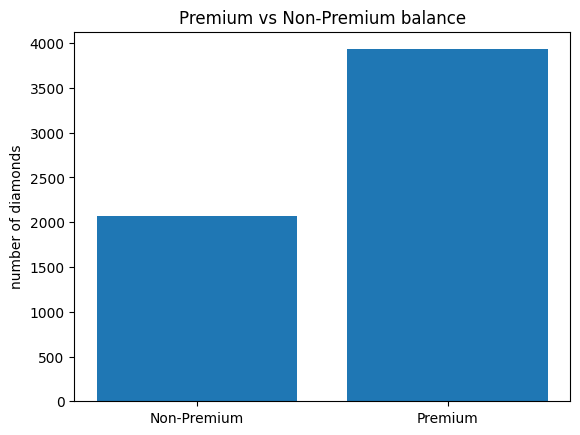

In [ ]:
CLASS_NAMES = ['Non-Premium', 'Premium']
sample['premium'] = sample['cut'].isin(['Premium', 'Ideal']).astype(int)

print("Original cut distribution:")
print(sample['cut'].value_counts())

counts = sample['premium'].value_counts().sort_index()
print('\nBinary target (premium):')
print(counts.rename(index=dict(enumerate(CLASS_NAMES))))
print('proportions:', (counts / counts.sum()).round(3).to_dict())

plt.figure()
plt.bar(CLASS_NAMES, counts.values)
plt.title('Premium vs Non-Premium balance')
plt.ylabel('number of diamonds')
plt.show()

**Note**:
- split is 65/35 (Premium vs Non-Premium)  
- moderately imbalanced, not extreme.
- We use macro-F1 alongside accuracy instead of resampling.

### Feature Correlations

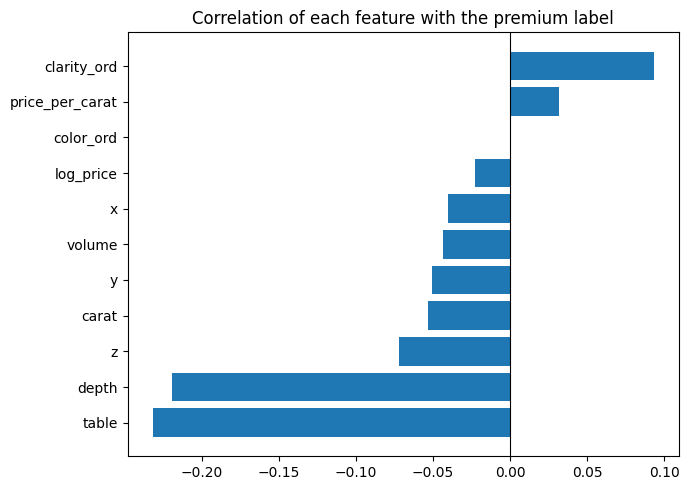

table             -0.232
depth             -0.219
z                 -0.072
carat             -0.053
y                 -0.050
volume            -0.044
x                 -0.041
log_price         -0.022
color_ord         -0.000
price_per_carat    0.032
clarity_ord        0.093
dtype: float64


In [ ]:
CLF_FEATURES = ['carat', 'depth', 'table', 'color_ord', 'clarity_ord', 'volume',
                'log_price', 'price_per_carat', 'x', 'y', 'z']

corr = pd.Series({f: np.corrcoef(sample[f], sample['premium'])[0, 1] for f in CLF_FEATURES}).sort_values()
plt.figure(figsize=(7, 5))
plt.barh(corr.index, corr.values)
plt.axvline(0, color='k', lw=0.8)
plt.title('Correlation of each feature with the premium label')
plt.tight_layout()
plt.show()
print(corr.round(3))

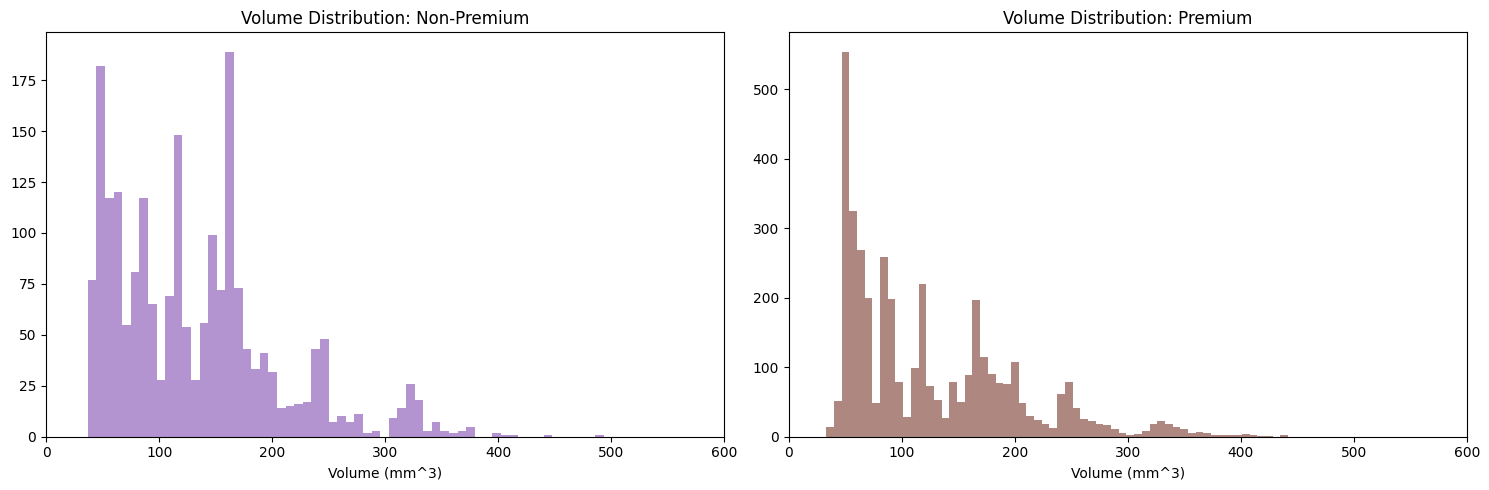

In [ ]:
def plot_stratified_dist(df, feature, title_suffix, x_label, x_lim=None):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    for cls in [0, 1]:
        ax[cls].hist(df.loc[df['premium'] == cls, feature], bins=60, color='C'+str(cls+4), alpha=0.7)
        ax[cls].set_title(f'{title_suffix}: {CLASS_NAMES[cls]}')
        ax[cls].set_xlabel(x_label)
        if x_lim: ax[cls].set_xlim(x_lim)
    plt.tight_layout()
    plt.show()

plot_stratified_dist(sample, 'volume', 'Volume Distribution', 'Volume (mm^3)', (0, 600))

### Helpers


In [ ]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion_matrix(y_true, y_pred, n_classes):
    M = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        M[t, p] += 1
    return M

def macro_f1(y_true, y_pred, n_classes):
    # unweighted mean of per-class F1
    f1s = []
    for c in range(n_classes):
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))
        prec = tp / (tp + fp) if tp + fp > 0 else 0.0
        rec  = tp / (tp + fn) if tp + fn > 0 else 0.0
        f1s.append(2 * prec * rec / (prec + rec) if prec + rec > 0 else 0.0)
    return np.mean(f1s)

def standardize_fit(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma == 0] = 1.0
    return mu, sigma

def standardize_apply(X, mu, sigma):
    return (X - mu) / sigma

def train_test_split(X, y, p_train=0.8, seed=0):
    # random split, not stratified
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    n_tr = int(p_train * len(X))
    tr, te = idx[:n_tr], idx[n_tr:]
    return (X[tr], y[tr]), (X[te], y[te])

In [ ]:
X = sample[CLF_FEATURES].to_numpy(float)
y = sample['premium'].to_numpy(int)

(X_tr, y_tr), (X_te, y_te) = train_test_split(X, y, seed=42)

# Standardization: fit on train, apply to both
mu, sigma = standardize_fit(X_tr)
X_tr_s = standardize_apply(X_tr, mu, sigma)
X_te_s = standardize_apply(X_te, mu, sigma)

print(f'Train set: {len(X_tr)} | Test set: {len(X_te)}')
print('after scaling: mean', X_tr_s.mean(axis=0).round(2), '| std', X_tr_s.std(axis=0).round(2))

Train set: 4799 | Test set: 1200
after scaling: mean [-0.  0. -0. -0.  0. -0. -0.  0.  0. -0.  0.] | std [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Setup**


*Data split* : 80/20 train/test with seed 42

*Standardization* : fit on train set only (to avoid data leakage); applied to both train and test

*Evaluation metrics* : accuracy and macro-F1 (robust to class imbalance)

*Features* : 11 features (carat, depth, table, ordinal color/clarity, volume, log_price, price_per_carat, x, y, z)

## Baseline Methods

### Gaussian Naive Bayes

Conditional independence assumption holds: once the class is known all feautres are considered independent. For a test sample *x*, we pick the class with the highest log-discriminant:

$$g_c(x) = \ln P(\omega_c) + \sum_j \ln N(x_j \mid \mu_{cj}, \sigma_{cj}^2)$$

where

$$\ln N(x_j \mid \mu_{cj}, \sigma_{cj}^2) = -\frac{1}{2}\ln(2\pi) - \ln \sigma_{cj} - \frac{(x_j - \mu_{cj})^2}{2\sigma_{cj}^2}.$$

Parameters $\mu_{cj}$, $\sigma_{cj}$, and $P(\omega_c)$ are estimated from the training data.

In [ ]:
def log_gaussian_pdf(x, mu, sigma):
    "Log of the Gaussian PDF (numerically stable form)."
    return -0.5 * np.log(2 * np.pi) - np.log(sigma) - ((x - mu) ** 2) / (2 * sigma ** 2)

def nb_fit(X, y, eps=1e-9):
    "Estimate per-class mean, std and prior."
    classes = np.unique(y)
    params = {}
    for c in classes:
        Xc = X[y == c]
        params[c] = {'mu': Xc.mean(axis=0), 'sigma': Xc.std(axis=0) + eps,
                     'log_prior': np.log(len(Xc) / len(X))}
    return classes, params

def nb_log_discriminant(X, p):
    return log_gaussian_pdf(X, p['mu'], p['sigma']).sum(axis=1) + p['log_prior']

def nb_predict(X, classes, params):
    scores = np.column_stack([nb_log_discriminant(X, params[c]) for c in classes])
    return classes[np.argmax(scores, axis=1)]

In [ ]:
classes, nb_params = nb_fit(X_tr_s, y_tr)
nb_pred = nb_predict(X_te_s, classes, nb_params)
print('Naive Bayes -- accuracy %.3f | macro-F1 %.3f' % (accuracy(y_te, nb_pred), macro_f1(y_te, nb_pred, 2)))
print(pd.DataFrame(confusion_matrix(y_te, nb_pred, 2), index=CLASS_NAMES, columns=CLASS_NAMES))

Naive Bayes -- accuracy 0.744 | macro-F1 0.695
             Non-Premium  Premium
Non-Premium          206      204
Premium              103      687


### k-Nearest Neighbors

 To classify a query point $x$, we find its $k$ nearest training points and assign the class by majority vote.

In [ ]:
def knn_predict_clf(X_train, y_train, X_query, k=15, n_classes=2, metric='euclidean'):
    preds = np.empty(len(X_query), dtype=int)
    for i, xq in enumerate(X_query):
        if metric == 'euclidean':
            d = np.sqrt(np.sum((X_train - xq) ** 2, axis=1))
        else:
            d = np.sum(np.abs(X_train - xq), axis=1)
        nn = np.argsort(d)[:k]
        preds[i] = np.argmax(np.bincount(y_train[nn], minlength=n_classes))
    return preds

knn_pred = knn_predict_clf(X_tr_s, y_tr, X_te_s, k=15)
print('k-NN (k=15) -- accuracy %.3f | macro-F1 %.3f' % (accuracy(y_te, knn_pred), macro_f1(y_te, knn_pred, 2)))
print(pd.DataFrame(confusion_matrix(y_te, knn_pred, 2), index=CLASS_NAMES, columns=CLASS_NAMES))

k-NN (k=15) -- accuracy 0.785 | macro-F1 0.726
             Non-Premium  Premium
Non-Premium          193      217
Premium               41      749


### Comparing Baselines

In [ ]:
majority = np.bincount(y_tr).argmax()
base_pred = np.full_like(y_te, majority)

rows = []
for name, pred in [('Majority baseline', base_pred), ('Naive Bayes', nb_pred), ('k-NN (k=15)', knn_pred)]:
    rows.append({
        'model': name,
        'accuracy': accuracy(y_te, pred),
        'macro_F1': macro_f1(y_te, pred, 2)
    })
results_clf = pd.DataFrame(rows).set_index('model').round(3)
results_clf

,accuracy,macro_F1
model,,
Majority baseline,0.658,0.397
Naive Bayes,0.744,0.695
k-NN (k=15),0.785,0.726


## Hyperparameter Analysis

### k-NN: the number of neighbours $k$

best k by test macro-F1: 7


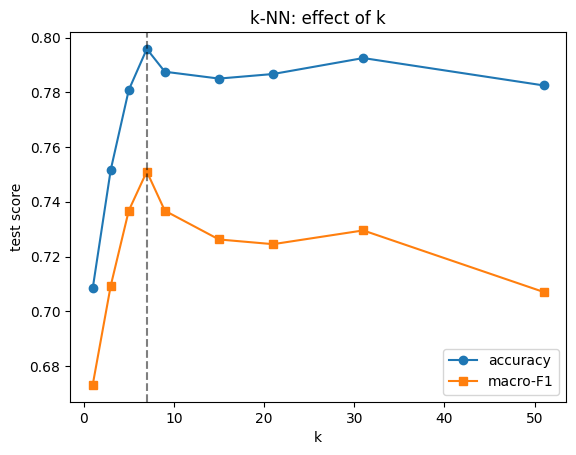

In [ ]:
k_values = [1, 3, 5, 7, 9, 15, 21, 31, 51]
test_acc, test_f1 = [], []
for k in k_values:
    p = knn_predict_clf(X_tr_s, y_tr, X_te_s, k=k)
    test_acc.append(accuracy(y_te, p))
    test_f1.append(macro_f1(y_te, p, 2))

best_k = k_values[int(np.argmax(test_f1))]
print('best k by test macro-F1:', best_k)

plt.figure()
plt.plot(k_values, test_acc, marker='o', label='accuracy')
plt.plot(k_values, test_f1, marker='s', label='macro-F1')
plt.axvline(best_k, color='k', ls='--', alpha=0.5)
plt.xlabel('k')
plt.ylabel('test score')
plt.title('k-NN: effect of k')
plt.legend()
plt.show()

In [ ]:
# Distance metric comparison
for metric in ['euclidean', 'manhattan']:
    p = knn_predict_clf(X_tr_s, y_tr, X_te_s, k=best_k, metric=metric)
    print('%-10s k=%d -> acc %.3f | macro-F1 %.3f' % (metric, best_k, accuracy(y_te, p), macro_f1(y_te, p, 2)))

euclidean  k=7 -> acc 0.796 | macro-F1 0.751
manhattan  k=7 -> acc 0.773 | macro-F1 0.720


## Random Forest

In [ ]:
def candidate_thresholds(col, max_thresh=16):
    "Generates candidate thresholds for splitting the tree"
    vals = np.unique(col)
    if len(vals) <= 1:
        return np.empty(0)
    if len(vals) <= max_thresh:
        return (vals[:-1] + vals[1:]) / 2.0
    qs = np.linspace(0, 1, max_thresh + 2)[1:-1]
    return np.unique(np.quantile(col, qs))

def gini(y, n_classes):
    counts = np.bincount(y, minlength=n_classes)
    p = counts / counts.sum()
    return 1.0 - np.sum(p ** 2)

In [ ]:
def build_tree_clf(X, y, n_classes, max_depth, min_split, min_leaf, m_feat, rng):
    def leaf(y):
        return {'leaf': True, 'probs': np.bincount(y, minlength=n_classes) / len(y)}

    def grow(X, y, depth):
        if depth >= max_depth or len(y) < min_split or np.all(y == y[0]):
            return leaf(y)

        feats = rng.choice(X.shape[1], size=min(m_feat, X.shape[1]), replace=False)
        parent = gini(y, n_classes)
        best = None
        for j in feats:
            col = X[:, j]
            for t in candidate_thresholds(col):
                left = col <= t
                nl = left.sum(); nr = len(y) - nl
                if nl < min_leaf or nr < min_leaf:
                    continue
                child = (nl * gini(y[left], n_classes) + nr * gini(y[~left], n_classes)) / len(y)
                gain = parent - child
                if best is None or gain > best[0]:
                    best = (gain, j, t, left)

        if best is None or best[0] <= 1e-12:
            return leaf(y)

        _, j, t, left = best
        return {'leaf': False, 'feature': j, 'threshold': t,
                'left':  grow(X[left],  y[left],  depth + 1),
                'right': grow(X[~left], y[~left], depth + 1)}

    return grow(X, y, 0)

In [ ]:
def tree_probs(node, X):
    def one(nd, x):
        while not nd['leaf']:
            nd = nd['left'] if x[nd['feature']] <= nd['threshold'] else nd['right']
        return nd['probs']
    return np.array([one(node, x) for x in X])

In [ ]:
def grow_full_tree(X, y, max_depth):
    rng = np.random.default_rng(0)
    return build_tree_clf(X, y, 2, max_depth, 2, 1, X.shape[1], rng)

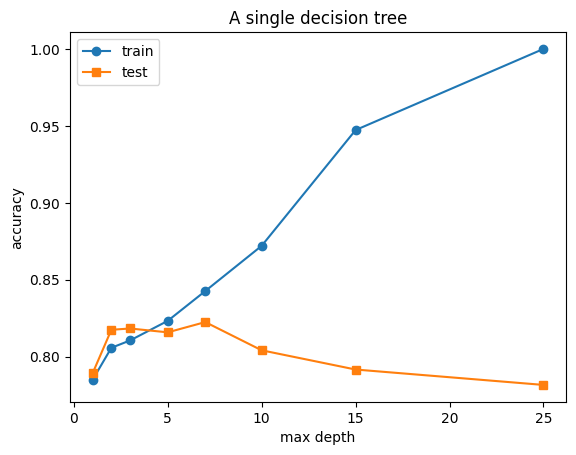

deepest single tree: train 1.000 / test 0.782


In [ ]:
depths = [1, 2, 3, 5, 7, 10, 15, 25]
tr_acc, te_acc = [], []
for dmax in depths:
    tree = grow_full_tree(X_tr_s, y_tr, dmax)
    tr_acc.append(accuracy(y_tr, np.argmax(tree_probs(tree, X_tr_s), axis=1)))
    te_acc.append(accuracy(y_te, np.argmax(tree_probs(tree, X_te_s), axis=1)))

plt.figure()
plt.plot(depths, tr_acc, marker='o', label='train')
plt.plot(depths, te_acc, marker='s', label='test')
plt.xlabel('max depth'); plt.ylabel('accuracy'); plt.title('A single decision tree')
plt.legend(); plt.show()
print('deepest single tree: train %.3f / test %.3f' % (tr_acc[-1], te_acc[-1]))

Comment: A single tree overfits.

In [ ]:
def rf_predict_clf(forest, X):
     # average predicted probabilities across all trees
    all_probs = np.array([tree_probs(tree, X) for tree in forest['trees']])
    avg_probs = np.mean(all_probs, axis=0)
    return np.argmax(avg_probs, axis=1)

In [ ]:
def rf_fit_clf(X, y, n_estimators=40, max_depth=12, min_split=10, min_leaf=5,
               max_features='sqrt', seed=0):
    # Trains a Random Forest classifier
    rng = np.random.default_rng(seed)
    n_classes = int(y.max() + 1)
    m_feat = int(np.sqrt(X.shape[1])) if max_features == 'sqrt' else (max_features or X.shape[1])
    trees = []
    for _ in range(n_estimators):
        idx = rng.integers(0, len(X), len(X))
        trees.append(build_tree_clf(X[idx], y[idx], n_classes, max_depth, min_split, min_leaf, m_feat, rng))
    return {'trees': trees, 'n_classes': n_classes}

forest = rf_fit_clf(X_tr_s, y_tr, n_estimators=40, max_depth=12, seed=0)
rf_pred = rf_predict_clf(forest, X_te_s)
print('Random Forest -- accuracy %.3f | macro-F1 %.3f' % (accuracy(y_te, rf_pred), macro_f1(y_te, rf_pred, 2)))
print(pd.DataFrame(confusion_matrix(y_te, rf_pred, 2), index=CLASS_NAMES, columns=CLASS_NAMES))
results_clf.loc['Random Forest'] = [accuracy(y_te, rf_pred), macro_f1(y_te, rf_pred, 2)]
results_clf.round(3)

Random Forest -- accuracy 0.834 | macro-F1 0.800
             Non-Premium  Premium
Non-Premium          254      156
Premium               43      747


,accuracy,macro_F1
model,,
Majority baseline,0.658,0.397
Naive Bayes,0.744,0.695
k-NN (k=15),0.785,0.726
Random Forest,0.834,0.800


### Random Forest hyperparameters

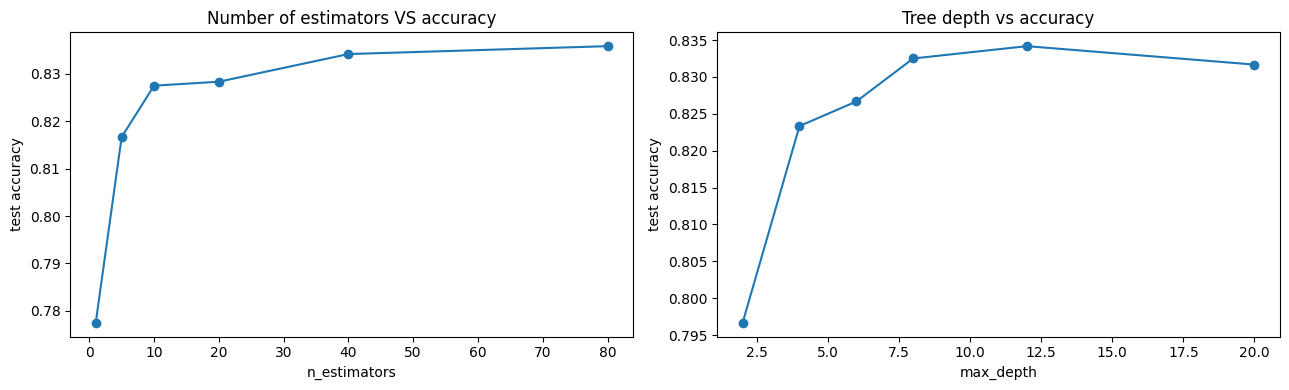

In [ ]:
n_grid = [1, 5, 10, 20, 40, 80]
acc_by_n = [accuracy(y_te, rf_predict_clf(rf_fit_clf(X_tr_s, y_tr, n_estimators=n, max_depth=12, seed=0), X_te_s))
            for n in n_grid]
depth_grid = [2, 4, 6, 8, 12, 20]
acc_by_depth = [accuracy(y_te, rf_predict_clf(rf_fit_clf(X_tr_s, y_tr, n_estimators=40, max_depth=d, seed=0), X_te_s))
                for d in depth_grid]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(n_grid, acc_by_n, marker='o'); ax[0].set_xlabel('n_estimators'); ax[0].set_ylabel('test accuracy')
ax[0].set_title('Number of estimators VS accuracy')
ax[1].plot(depth_grid, acc_by_depth, marker='o'); ax[1].set_xlabel('max_depth'); ax[1].set_ylabel('test accuracy')
ax[1].set_title('Tree depth vs accuracy')
plt.tight_layout(); plt.show()

Comment: Both curves flatten out fast. More trees or deeper trees stop helping after a point.

In [ ]:
# Effect of max_features (random subspace)
print("Effect of max_features (random subspace size):")
for mf in [1, 2, 3, len(CLF_FEATURES)]:
    f = rf_fit_clf(X_tr_s, y_tr, n_estimators=40, max_depth=12, max_features=mf, seed=0)
    print('max_features = %-2s -> test acc %.3f' % (mf, accuracy(y_te, rf_predict_clf(f, X_te_s))))

Effect of max_features (random subspace size):
max_features = 1  -> test acc 0.823
max_features = 2  -> test acc 0.833
max_features = 3  -> test acc 0.834
max_features = 11 -> test acc 0.840


### Baseline vs. Extension Comparison

In [ ]:
comparison_clf = results_clf.copy()
comparison_clf['type'] = ['Baseline', 'Baseline', 'Baseline', 'Extension']
print("\nClassification: Baseline vs Extension")
print(comparison_clf[['type', 'accuracy', 'macro_F1']].round(3))


Classification: Baseline vs Extension
                        type  accuracy  macro_F1
model                                           
Majority baseline   Baseline     0.658     0.397
Naive Bayes         Baseline     0.744     0.695
k-NN (k=15)         Baseline     0.785     0.726
Random Forest      Extension     0.834     0.800


---
# PART B — Regression: predicting price

We now predict a diamond's **price** (USD).

### Research questions

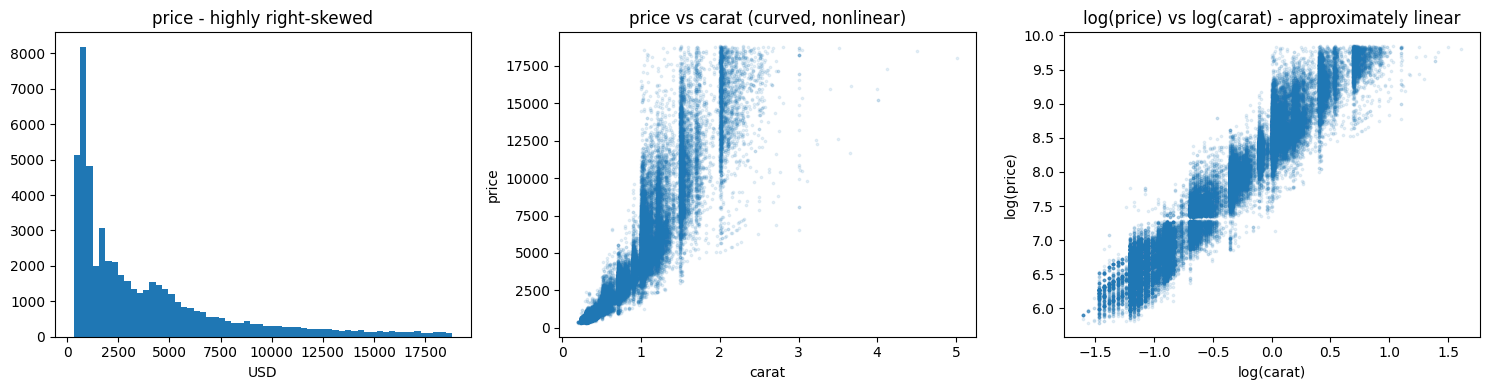

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(data['price'], bins=60)
ax[0].set_title('price - highly right-skewed')
ax[0].set_xlabel('USD')

ax[1].scatter(data['carat'], data['price'], s=3, alpha=0.1)
ax[1].set_title('price vs carat (curved, nonlinear)')
ax[1].set_xlabel('carat')
ax[1].set_ylabel('price')

ax[2].scatter(np.log(data['carat']), np.log(data['price']), s=3, alpha=0.1)
ax[2].set_title('log(price) vs log(carat) - approximately linear')
ax[2].set_xlabel('log(carat)')
ax[2].set_ylabel('log(price)')

plt.tight_layout()
plt.show()

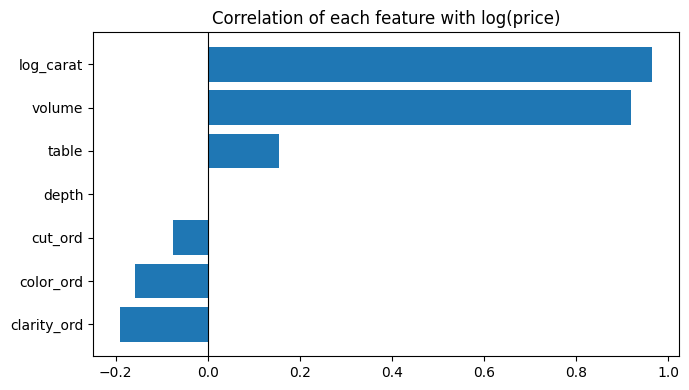

,0
clarity_ord,-0.191
color_ord,-0.157
cut_ord,-0.076
depth,0.002
table,0.156
volume,0.920
log_carat,0.965


In [ ]:
REG_FEATURES = ['log_carat', 'volume', 'depth', 'table', 'color_ord', 'clarity_ord', 'cut_ord']

corr_lp = pd.Series({f: np.corrcoef(sample[f], np.log(sample['price']))[0, 1] for f in REG_FEATURES}).sort_values()
plt.figure(figsize=(7, 4))
plt.barh(corr_lp.index, corr_lp.values); plt.axvline(0, color='k', lw=0.8)
plt.title('Correlation of each feature with log(price)')
plt.tight_layout(); plt.show()
corr_lp.round(3)

In [ ]:
def rmse(y, p): return np.sqrt(np.mean((y - p) ** 2))
def mae(y, p):  return np.mean(np.abs(y - p))
def r2_score_scratch(y, p):
    ss_res = np.sum((y - p) ** 2); ss_tot = np.sum((y - y.mean()) ** 2)
    return 1.0 - ss_res / ss_tot

def report_price(name, y_price_true, y_log_pred):
    "Report R2 on the log scale and RMSE back in dollars."
    y_log_true = np.log(y_price_true)
    r2_log = r2_score_scratch(y_log_true, y_log_pred)
    rmse_usd = rmse(y_price_true, np.exp(y_log_pred))
    print('%-22s R2(log) %.3f | RMSE $%.0f' % (name, r2_log, rmse_usd))
    return r2_log, rmse_usd

In [ ]:
Xr = sample[REG_FEATURES].to_numpy(float)
price = sample['price'].to_numpy(float)
yr = np.log(price)                                   # regression target = log(price)

(Xr_tr, yr_tr), (Xr_te, yr_te) = train_test_split(Xr, yr, seed=42)
price_te = np.exp(yr_te)
rmu, rsg = standardize_fit(Xr_tr)
Xr_tr_s = standardize_apply(Xr_tr, rmu, rsg)
Xr_te_s = standardize_apply(Xr_te, rmu, rsg)
print('train/test:', len(Xr_tr), len(Xr_te))

train/test: 4800 1200


##Linear regression - and how much is carat alone?

First the closed-form **normal equation** $\boldsymbol\theta = (X^\top X)^{-1} X^\top \mathbf{t}$ on a
single feature (`log_carat`), then on all features, then **gradient descent** as a cross-check.

In [ ]:
def add_bias(X):
    return np.column_stack([np.ones(len(X)), X])

def direct_solution(X, t):
    "Closed-form least squares (X already has a bias column)."
    return np.linalg.solve(X.T @ X, X.T @ t)

# (a) carat only
j_carat = REG_FEATURES.index('log_carat')
th1 = direct_solution(add_bias(Xr_tr_s[:, [j_carat]]), yr_tr)
pred1 = add_bias(Xr_te_s[:, [j_carat]]) @ th1
report_price('log_carat only', price_te, pred1)

# (b) all features
theta = direct_solution(add_bias(Xr_tr_s), yr_tr)
lin_pred = add_bias(Xr_te_s) @ theta
report_price('all features', price_te, lin_pred)

log_carat only         R2(log) 0.929 | RMSE $1537
all features           R2(log) 0.977 | RMSE $793


(np.float64(0.9769888468689202), np.float64(792.5795740245873))

In [ ]:
def gradient_descent(X, t, alpha=0.1, num_iters=3000):
    theta = np.zeros(X.shape[1]); n = len(t); history = []
    for _ in range(num_iters):
        grad = (X.T @ (X @ theta - t)) / n
        theta = theta - alpha * grad
        history.append(0.5 * np.mean((X @ theta - t) ** 2))
    return theta, history

theta_gd, history = gradient_descent(add_bias(Xr_tr_s), yr_tr, alpha=0.1, num_iters=3000)
print('max|theta_gd - theta_normal| = %.2e' % np.max(np.abs(theta_gd - theta)))
plt.figure(); plt.plot(history); plt.xlabel('iteration'); plt.ylabel('cost J')
plt.title('Gradient descent converges to the closed-form solution'); plt.show()

In [ ]:
coef = pd.Series(theta[1:], index=REG_FEATURES)
print('linear coefficients (standardized features):')
print(coef.round(3))
print('\nraw marginal corr with log(price): color %.3f, clarity %.3f'
      % (np.corrcoef(sample['color_ord'], np.log(sample['price']))[0, 1],
         np.corrcoef(sample['clarity_ord'], np.log(sample['price']))[0, 1]))